# AlphaQuoridor — Training Stats Viewer
Reads `stats.csv` from the active variant's logs folder (respects `USE_BFS_CHANNELS` from `config.py`).

In [ ]:
# ── Load data ────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(''))   # find config.py in workspace root

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from config import LOGS_DIR, USE_BFS_CHANNELS

CSV_PATH = os.path.join(LOGS_DIR, 'stats.csv')
# on_bad_lines='skip' guards against rows with a mismatched column count
# (e.g. a row written by a different code version during a schema transition)
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

# Coerce numeric (some cols are empty strings when not promoted or not yet tracked)
for col in ['vs_random', 'vs_greedy', 'vs_bfs', 'sp_avg_game_len', 'sp_avg_walls']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

variant = f"{'8-ch BFS' if USE_BFS_CHANNELS else '6-ch'}"
print(f"Loaded {len(df)} cycles from {CSV_PATH}  [{variant}]")
df.tail(9)


Loaded 2 cycles from ./logs_8ch\stats.csv  [8-ch BFS]


,,cycle,timestamp,sp_W_pct,sp_D_pct,sp_L_pct,sp_positions,sp_unique,sp_entropy,sp_top1,loss,...,eval_score,promoted,vs_random,vs_greedy,vs_bfs,t_selfplay_min,t_train_min,t_evalnet_min,t_evalbest_min,t_cycle_min
5,19:12:03,57.5,6.0,36.5,5311,180,7.43,4,26.6,9.3,1.0913,...,1.00,1,NaN,0.5,0.5,41.3,6.0,5.1,1.4,53.7
6,20:05:48,75.5,4.0,20.5,4312,156,7.06,9,21.6,6.8,1.0816,...,0.55,1,NaN,1.0,1.0,33.7,5.2,9.9,1.4,50.2


In [75]:
# ── Summary table ────────────────────────────────────────────────────────────
total_h = df['t_cycle_min'].sum() / 60
promoted_n = df['promoted'].sum()
print(f"Cycles run:      {len(df)}")
print(f"Promoted:        {int(promoted_n)}  ({100*promoted_n/len(df):.0f}%)")
print(f"Total wall time: {total_h:.1f} h  ({df['t_cycle_min'].mean():.1f} min/cycle avg)")
print(f"Last eval score: {df['eval_score'].iloc[-1]:.4f}")
print(f"Last entropy:    {df['sp_entropy'].iloc[-1]:.2f} bits  (top-1: {int(df['sp_top1'].iloc[-1])}x)")
if 'sp_avg_game_len' in df.columns:
    print(f"Last avg game:   {df['sp_avg_game_len'].iloc[-1]:.1f} plies  |  {df['sp_avg_walls'].iloc[-1]:.1f} walls placed")
print()

df['t_cumulative_h'] = df['t_cycle_min'].cumsum() / 60

cols = ['cycle', 't_cumulative_h', 'sp_W_pct', 'sp_D_pct', 'sp_entropy', 'sp_top1',
        'sp_avg_game_len', 'sp_avg_walls',
        'loss', 'loss_value', 'eval_score', 'promoted', 'vs_greedy', 'vs_bfs', 't_cycle_min']
# Only keep cols that exist (graceful degradation on old CSV without new cols)
cols = [c for c in cols if c in df.columns]

fmt = {
    'sp_W_pct': '{:.0f}%', 'sp_D_pct': '{:.0f}%',
    'sp_entropy': '{:.2f}', 'loss': '{:.4f}',
    'loss_value': '{:.4f}', 'eval_score': '{:.4f}',
    'sp_avg_game_len': '{:.1f}', 'sp_avg_walls': '{:.1f}',
    'vs_greedy': lambda v: f'{v:.2f}' if pd.notna(v) else '',
    'vs_bfs':    lambda v: f'{v:.2f}' if pd.notna(v) else '',
    't_cycle_min': '{:.1f}', 't_cumulative_h': '{:.2f}h',
}
fmt = {k: v for k, v in fmt.items() if k in cols}

styled = df[cols].tail(10).style.format(fmt) \
    .background_gradient(subset=['eval_score'], cmap='RdYlGn', vmin=0, vmax=1) \
    .background_gradient(subset=['sp_entropy'], cmap='RdYlGn', vmin=5, vmax=8)
if 'vs_greedy' in cols:
    styled = styled.background_gradient(subset=['vs_greedy'], cmap='RdYlGn', vmin=0, vmax=1)
if 'vs_bfs' in cols:
    styled = styled.background_gradient(subset=['vs_bfs'], cmap='RdYlGn', vmin=0, vmax=1)
if 'sp_avg_walls' in cols:
    styled = styled.background_gradient(subset=['sp_avg_walls'], cmap='Blues', vmin=0)
styled


Cycles run:      2
Promoted:        2  (100%)
Total wall time: 1.7 h  (52.0 min/cycle avg)
Last eval score: 0.5500
Last entropy:    21.60 bits  (top-1: 6x)



,,cycle,t_cumulative_h,sp_W_pct,sp_D_pct,sp_entropy,sp_top1,loss,loss_value,eval_score,promoted,vs_greedy,vs_bfs,t_cycle_min
5,19:12:03,57.500000,0.90h,36%,5311%,26.60,9.300000,1.0913,0.1201,1.0000,1,0.50,0.50,53.7
6,20:05:48,75.500000,1.73h,20%,4312%,21.60,6.800000,1.0816,0.1299,0.5500,1,1.00,1.00,50.2


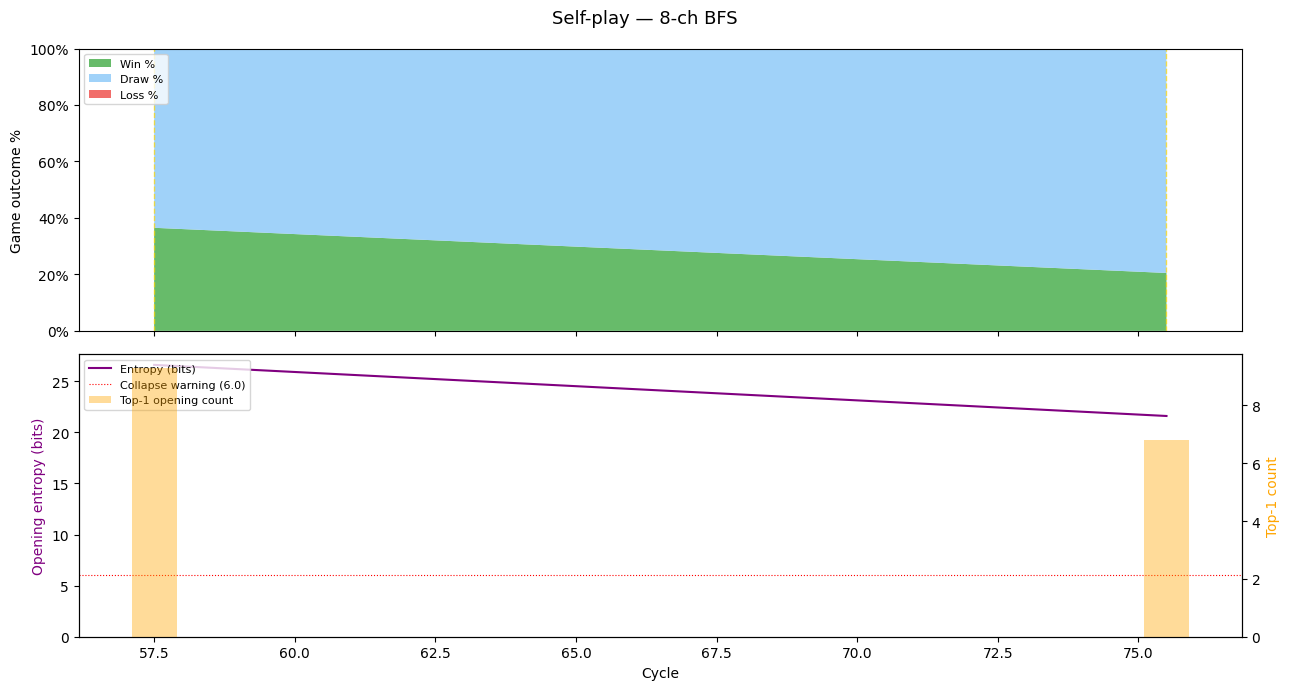

In [76]:
# ── Self-play outcomes + opening entropy ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle(f'Self-play — {variant}', fontsize=13)

# Stacked W/D/L %
ax = axes[0]
ax.stackplot(df['cycle'], df['sp_W_pct'], df['sp_D_pct'], df['sp_L_pct'],
             labels=['Win %', 'Draw %', 'Loss %'],
             colors=['#4caf50', '#90caf9', '#ef5350'], alpha=0.85)
ax.set_ylabel('Game outcome %')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d%%'))
# Mark promotions
for _, row in df[df['promoted'] == 1].iterrows():
    ax.axvline(row['cycle'], color='gold', linewidth=1, linestyle='--', alpha=0.7)

# Entropy + unique openings
ax2 = axes[1]
ax2.plot(df['cycle'], df['sp_entropy'], color='purple', label='Entropy (bits)')
ax2.axhline(6.0, color='red', linewidth=0.8, linestyle=':', label='Collapse warning (6.0)')
ax2.set_ylabel('Opening entropy (bits)', color='purple')
ax2.set_ylim(0)
ax3 = ax2.twinx()
ax3.bar(df['cycle'], df['sp_top1'], color='orange', alpha=0.4, label='Top-1 opening count')
ax3.set_ylabel('Top-1 count', color='orange')
ax2.set_xlabel('Cycle')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

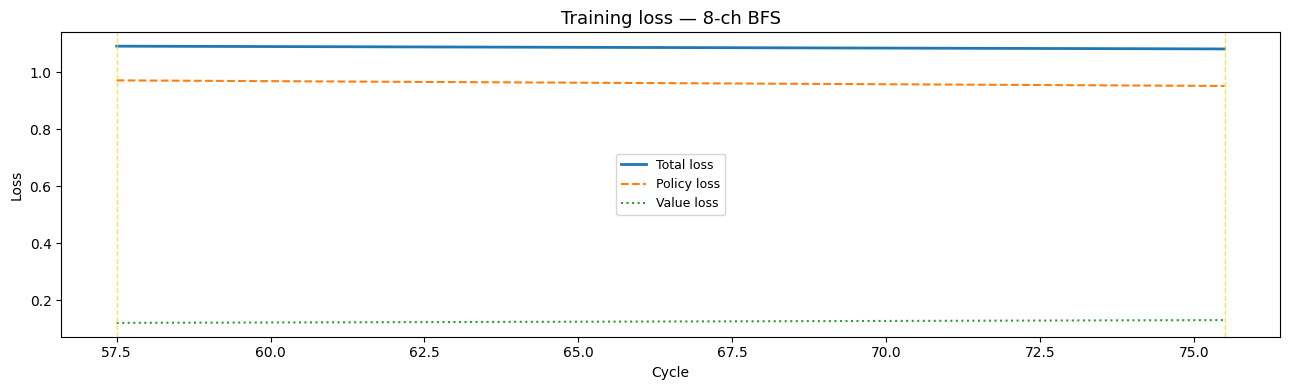

In [77]:
# ── Training loss ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title(f'Training loss — {variant}', fontsize=13)
ax.plot(df['cycle'], df['loss'],        label='Total loss',   linewidth=2)
ax.plot(df['cycle'], df['loss_policy'], label='Policy loss',  linestyle='--')
ax.plot(df['cycle'], df['loss_value'],  label='Value loss',   linestyle=':')
for _, row in df[df['promoted'] == 1].iterrows():
    ax.axvline(row['cycle'], color='gold', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xlabel('Cycle')
ax.set_ylabel('Loss')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

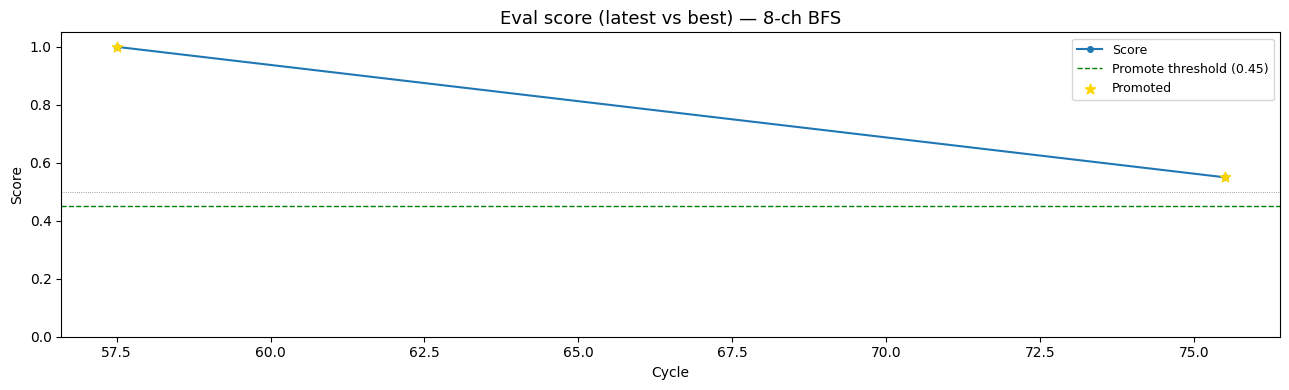

In [78]:
# ── Eval score + promotions ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title(f'Eval score (latest vs best) — {variant}', fontsize=13)
ax.plot(df['cycle'], df['eval_score'], marker='o', markersize=4, linewidth=1.5, label='Score')
ax.axhline(0.45, color='green', linewidth=1, linestyle='--', label='Promote threshold (0.45)')
ax.axhline(0.5,  color='gray',  linewidth=0.6, linestyle=':')
promoted = df[df['promoted'] == 1]
ax.scatter(promoted['cycle'], promoted['eval_score'], color='gold', zorder=5,
           s=60, label='Promoted', marker='*')
ax.set_xlabel('Cycle')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

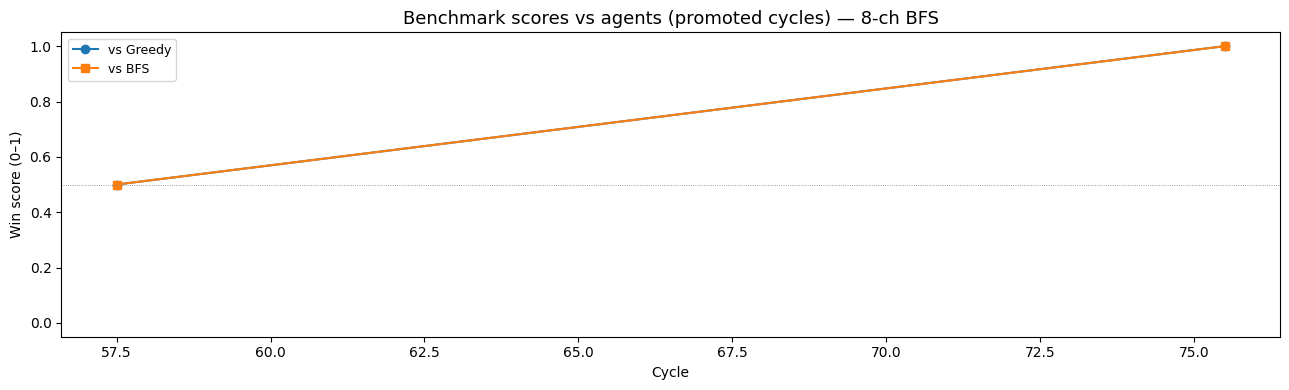

In [79]:
# ── Benchmark scores (promoted cycles only) ──────────────────────────────────
bench = df[df['promoted'] == 1].copy()
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title(f'Benchmark scores vs agents (promoted cycles) — {variant}', fontsize=13)
if bench['vs_greedy'].notna().any():
    ax.plot(bench['cycle'], bench['vs_greedy'], marker='o', label='vs Greedy')
if bench['vs_bfs'].notna().any():
    ax.plot(bench['cycle'], bench['vs_bfs'],    marker='s', label='vs BFS')
if bench['vs_random'].notna().any():
    ax.plot(bench['cycle'], bench['vs_random'], marker='^', label='vs Random')
ax.axhline(0.5, color='gray', linewidth=0.6, linestyle=':')
ax.set_xlabel('Cycle')
ax.set_ylabel('Win score (0–1)')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

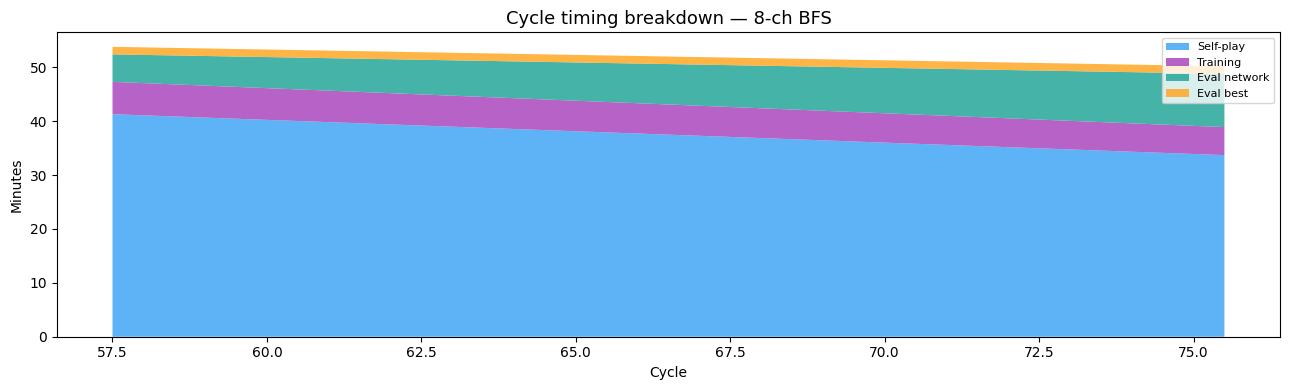

In [80]:
# ── Cycle timing breakdown ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title(f'Cycle timing breakdown — {variant}', fontsize=13)
ax.stackplot(df['cycle'],
             df['t_selfplay_min'], df['t_train_min'],
             df['t_evalnet_min'],  df['t_evalbest_min'],
             labels=['Self-play', 'Training', 'Eval network', 'Eval best'],
             colors=['#42a5f5', '#ab47bc', '#26a69a', '#ffa726'], alpha=0.85)
ax.set_xlabel('Cycle')
ax.set_ylabel('Minutes')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [81]:
# ── Game length & walls placed ───────────────────────────────────────────────
if 'sp_avg_game_len' not in df.columns:
    print("No sp_avg_game_len column yet — run at least one cycle with the updated code.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.set_title(f'Avg game length & walls placed per game — {variant}', fontsize=13)

    color_len  = '#1976d2'
    color_wall = '#e65100'

    ax.plot(df['cycle'], df['sp_avg_game_len'], color=color_len,  linewidth=2, label='Avg game length (plies)')
    ax.set_ylabel('Avg game length (plies)', color=color_len)
    ax.tick_params(axis='y', labelcolor=color_len)

    ax2 = ax.twinx()
    ax2.plot(df['cycle'], df['sp_avg_walls'], color=color_wall, linewidth=2, linestyle='--', label='Avg walls placed')
    ax2.set_ylabel('Avg walls placed', color=color_wall)
    ax2.tick_params(axis='y', labelcolor=color_wall)
    ax2.set_ylim(bottom=0)

    for _, row in df[df['promoted'] == 1].iterrows():
        ax.axvline(row['cycle'], color='gold', linewidth=1, linestyle='--', alpha=0.7)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    ax.set_xlabel('Cycle')
    plt.tight_layout()
    plt.show()


No sp_avg_game_len column yet — run at least one cycle with the updated code.
